# Exercício 12 — Gerando variáveis Poisson correlacionadas

**Enunciado:** Imagine que nosso objetivo seja gerar realizações de duas variáveis aleatórias tais que
$X \sim \text{Poisson}(\mu_X)$ e $Y \sim \text{Poisson}(\mu_Y)$, mas de forma que $\rho_{XY} = \text{corr}(X,Y) \ne 0$.
Uma forma de fazê-lo é amostrar valores da seguinte distribuição conjunta:

$$\mathbb{P}(X=x, Y=y) = \exp[-(\mu_X + \mu_Y - \theta)] \frac{(\mu_X-\theta)^x}{x!}\frac{(\mu_Y-\theta)^y}{y!} \sum_{i=0}^{\min(x,y)} \binom{x}{i}\binom{y}{i} i! \left[\frac{\theta}{(\mu_X-\theta)(\mu_Y-\theta)}\right]^i, \qquad (5)$$

onde $0 \le \theta < \min\{\mu_X, \mu_Y\}$.

- (a) Implemente uma função que retorne um conjunto de pares $\{(x_i,y_i)\}_{i=1}^n$ amostrados de acordo com a distribuição de probabilidade definida na Eq. (5). Visualize os resultados através de histogramas bidimensionais.
- (b) Elabore uma maneira alternativa de gerar variáveis aleatórias de Poisson $(X,Y)$ correlacionadas através da soma de variáveis aleatórias independentes.
- (c) Com o método de (b), calcule analiticamente a covariância $cov(X,Y)$ e o coeficiente de correlação $\rho_{X,Y} = corr(X,Y)$ das variáveis aleatórias cuja PMF conjunta é dada pela Eq. (5).
- (d) Os métodos mencionados acima não permitem gerar correlações negativas ($\rho_{X,Y} \ge 0$ sempre — por que?). No entanto, em certas aplicações é necessário empregar distribuições que produzam variáveis discretas com correlação negativa ($\rho_{XY} < 0$). Em [1], os autores definiram a distribuição de probabilidade conjunta

$$\mathbb{P}(X=x,Y=y) = K\frac{\lambda_X^x \lambda_Y^y \lambda^{xy}}{x!y!}, \qquad (6)$$

onde $x,y=0,1,2,\dots$; $(\lambda_X,\lambda_Y)>0$; $0<\lambda\le 1$; e $K$ é a constante de normalização. Para
$0<\lambda<1$, $cov(X,Y)<0$, e as condicionais são $X|Y=y \sim \text{Poisson}(\lambda_X\lambda^y)$ e
$Y|X=x \sim \text{Poisson}(\lambda_Y\lambda^x)$. Implemente uma função que receba $(\lambda_X,\lambda_Y,\lambda)$
e retorne um conjunto de dados amostrados pela distribuição (6), e mostre que é possível gerar variáveis
negativamente correlacionadas.

> [1] Ghosh, I., Marques, F., & Chakraborty, S. (2021). *A new bivariate Poisson distribution via conditional
> specification: properties and applications.* Journal of Applied Statistics, 48(16), 3025–3047. (PDF
> disponibilizado pelo professor, salvo em `ghosh2021NewBivariate.pdf` nesta mesma pasta.)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb, factorial

rng = np.random.default_rng(42)


## Item (a)

**Enunciado:** Implemente uma função que retorne um conjunto de pares $\{(x_i,y_i)\}_{i=1}^n$ amostrados de
acordo com a distribuição de probabilidade definida na Eq. (5). Visualize os resultados através de
histogramas bidimensionais para $\rho_{XY} > 0$ e $\rho_{XY} = 0$.

**Solução:**

A forma mais direta (sem usar nenhum truque, só a definição mesmo) é: como $X$ e $Y$ são não-negativos e
inteiros, eu monto uma grade truncada com a PMF da Eq. (5) para $x, y = 0, \dots, k_{max}$ (usando $k_{max}$
grande o suficiente pra pegar praticamente toda a massa de probabilidade), normalizo essa grade (a soma já
fica bem próxima de 1, mas eu normalizo de novo por segurança), e depois amostro um par $(x,y)$ por vez
usando `rng.choice` sobre os índices da grade "achatada" (é basicamente inverter a CDF de uma variável
categórica). Isso funciona pra qualquer PMF discreta com suporte truncável, não só essa.

In [2]:
def joint_pmf_grid(mu_x, mu_y, theta, k_max):
    """Grade (k_max+1) x (k_max+1) com P(X=x, Y=y) da Eq. (5), x,y = 0..k_max."""
    grid = np.zeros((k_max + 1, k_max + 1))
    ratio = theta / ((mu_x - theta) * (mu_y - theta))

    for x in range(k_max + 1):
        for y in range(k_max + 1):
            soma = sum(comb(x, i) * comb(y, i) * factorial(i) * ratio ** i
                       for i in range(min(x, y) + 1))
            grid[x, y] = (np.exp(-(mu_x + mu_y - theta))
                          * (mu_x - theta) ** x / factorial(x)
                          * (mu_y - theta) ** y / factorial(y)
                          * soma)
    return grid


def sample_poisson_corr(mu_x, mu_y, theta, n, rng, k_max=40):
    """Amostra n pares (x_i, y_i) da PMF conjunta da Eq. (5)."""
    grid = joint_pmf_grid(mu_x, mu_y, theta, k_max)
    p = grid.ravel()
    p = p / p.sum()

    idx = rng.choice(len(p), size=n, p=p)
    xs, ys = np.divmod(idx, k_max + 1)
    return xs, ys


# checagem: a massa de probabilidade truncada em k_max=40 deve somar ~1
print("soma da PMF truncada (mu_x=4, mu_y=3, theta=2):", joint_pmf_grid(4, 3, 2, 40).sum())


soma da PMF truncada (mu_x=4, mu_y=3, theta=2): 1.0


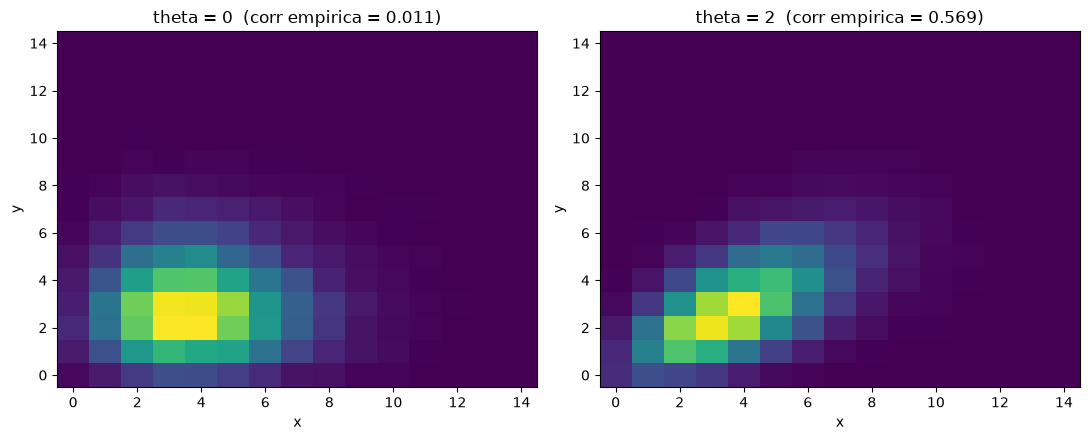

In [3]:
mu_x, mu_y = 4, 3

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

for j, theta in enumerate([0, 2]):
    x, y = sample_poisson_corr(mu_x, mu_y, theta, 20_000, rng)
    corr = np.corrcoef(x, y)[0, 1]
    ax[j].hist2d(x, y, bins=np.arange(-0.5, 15.5), cmap='viridis')
    ax[j].set_title(f'theta = {theta}  (corr empirica = {corr:.3f})')
    ax[j].set_xlabel('x')
    ax[j].set_ylabel('y')

plt.tight_layout()
plt.show()


## Item (b)

**Enunciado:** Elabore uma maneira alternativa de gerar variáveis aleatórias de Poisson $(X,Y)$
correlacionadas através da soma de variáveis aleatórias independentes.

**Solução:**

Uma forma clássica (chamada de "trivariate reduction" ou redução trivariada) é definir três variáveis
independentes $Z_1 \sim \text{Poisson}(\mu_X - \theta)$, $Z_2 \sim \text{Poisson}(\mu_Y - \theta)$,
$Z_3 \sim \text{Poisson}(\theta)$, e então

$$X = Z_1 + Z_3, \qquad Y = Z_2 + Z_3.$$

A ideia é que $Z_3$ é a parte "compartilhada" entre $X$ e $Y$: quando $Z_3$ sai grande, tanto $X$ quanto $Y$
tendem a ficar maiores, criando a correlação positiva. Como soma de Poissons independentes é Poisson,
$X \sim \text{Poisson}(\mu_X)$ e $Y \sim \text{Poisson}(\mu_Y)$ marginalmente, exatamente como pedido. Pode-se
mostrar (é um resultado conhecido, a distribuição de Holgate) que o par $(X,Y)$ construído assim tem
exatamente a PMF conjunta da Eq. (5) — abaixo eu comparo empiricamente com o método (a) pra conferir isso.

In [4]:
def sample_poisson_trivariate(mu_x, mu_y, theta, n, rng):
    """X = Z1+Z3, Y = Z2+Z3, com Z1,Z2,Z3 Poisson independentes."""
    z1 = rng.poisson(mu_x - theta, size=n)
    z2 = rng.poisson(mu_y - theta, size=n)
    z3 = rng.poisson(theta, size=n)
    return z1 + z3, z2 + z3


x_a, y_a = sample_poisson_corr(mu_x, mu_y, 2, 20_000, rng)
x_b, y_b = sample_poisson_trivariate(mu_x, mu_y, 2, 20_000, rng)

print("metodo (a) - PMF direta:      media x =", x_a.mean(), " media y =", y_a.mean(),
      " corr =", np.corrcoef(x_a, y_a)[0, 1])
print("metodo (b) - soma de Poisson: media x =", x_b.mean(), " media y =", y_b.mean(),
      " corr =", np.corrcoef(x_b, y_b)[0, 1])


metodo (a) - PMF direta:      media x = 3.9964  media y = 3.0028  corr = 0.5815190319119127
metodo (b) - soma de Poisson: media x = 4.00225  media y = 3.00265  corr = 0.5697495785373459


## Item (c)

**Enunciado:** Com o método de (b), calcule analiticamente a covariância $cov(X,Y)$ e o coeficiente de
correlação $\rho_{X,Y} = corr(X,Y)$ das variáveis aleatórias cuja PMF conjunta é dada pela Eq. (5).

**Solução:**

Usando $X = Z_1+Z_3$ e $Y=Z_2+Z_3$ com $Z_1,Z_2,Z_3$ independentes:

$$Var(X) = Var(Z_1) + Var(Z_3) = (\mu_X-\theta) + \theta = \mu_X, \qquad Var(Y) = \mu_Y,$$

(usando que a variância de uma Poisson($\mu$) é igual a $\mu$, e que a variância da soma de independentes é a
soma das variâncias). Já a covariância:

$$Cov(X,Y) = Cov(Z_1+Z_3,\, Z_2+Z_3) = Cov(Z_1,Z_2) + Cov(Z_1,Z_3) + Cov(Z_3,Z_2) + Cov(Z_3,Z_3).$$

Como $Z_1, Z_2, Z_3$ são independentes entre si, todos os termos de covariância cruzada são 0, sobrando só
$Cov(Z_3,Z_3) = Var(Z_3) = \theta$. Logo:

$$Cov(X,Y) = \theta, \qquad \rho_{X,Y} = \frac{Cov(X,Y)}{\sqrt{Var(X)Var(Y)}} = \frac{\theta}{\sqrt{\mu_X \mu_Y}}.$$

Como $0 \le \theta < \min\{\mu_X,\mu_Y\}$, essa correlação é sempre **maior ou igual a zero**. Abaixo eu
confirmo numericamente que a covariância e a correlação empíricas batem com essas expressões.

In [5]:
theta = 2
x, y = sample_poisson_trivariate(mu_x, mu_y, theta, 200_000, rng)

cov_emp = np.cov(x, y)[0, 1]
rho_emp = np.corrcoef(x, y)[0, 1]

print(f"cov empirica  = {cov_emp:.4f}   (teorico: theta = {theta})")
print(f"rho empirica  = {rho_emp:.4f}   (teorico: theta/sqrt(mu_x*mu_y) = {theta/np.sqrt(mu_x*mu_y):.4f})")


cov empirica  = 1.9880   (teorico: theta = 2)
rho empirica  = 0.5752   (teorico: theta/sqrt(mu_x*mu_y) = 0.5774)


## Item (d)

**Enunciado:** Os métodos (a)–(c) não permitem gerar correlações negativas ($\rho_{X,Y} \ge 0$ sempre — por
quê?). Implemente uma função que receba $(\lambda_X,\lambda_Y,\lambda)$ e retorne um conjunto de dados
amostrados pela distribuição da Eq. (6), definida por Ghosh, Marques & Chakraborty (2021) [1] através das
condicionais $X|Y=y \sim \text{Poisson}(\lambda_X\lambda^y)$ e $Y|X=x \sim \text{Poisson}(\lambda_Y\lambda^x)$,
e mostre que com essa distribuição é possível gerar variáveis negativamente correlacionadas.

**Solução:**

Pela conta do item (c), $Cov(X,Y) = \theta$ com $\theta \ge 0$ por definição (é a taxa de um $Z_3 \sim
\text{Poisson}(\theta)$, então não pode ser negativa). Por isso qualquer construção baseada em soma de
variáveis Poisson independentes — como os métodos (a) e (b), que são a mesma distribuição vista de dois
jeitos — só consegue gerar $\rho_{X,Y} \ge 0$: a "parte compartilhada" $Z_3$ só pode empurrar $X$ e $Y$ para o
mesmo lado, nunca para lados opostos.

O artigo de Ghosh, Marques & Chakraborty (2021) [1] contorna isso definindo a distribuição direto pelas
**condicionais** (Eq. 2 do artigo, seção 2), em vez de construir o par a partir de uma soma:

$$X \mid Y=y \sim \text{Poisson}(\lambda_X \lambda^y), \qquad Y \mid X=x \sim \text{Poisson}(\lambda_Y \lambda^x).$$

Os autores mostram (Teorema 3.1 do artigo) que essa especificação sempre gera $Cov(X,Y) < 0$ quando $0 <
\lambda < 1$ (e independência quando $\lambda=1$). O problema é que a constante de normalização $K$ da PMF
conjunta envolve uma soma dupla infinita (Eq. (1)/(7) do artigo) sem forma fechada simples, então amostrar
direto da PMF (como fiz no item (a)) seria bem mais complicado aqui.

Em vez disso, dá pra amostrar usando as próprias condicionais através de um **amostrador de Gibbs**: começo
com $X,Y$ quaisquer, e alterno amostrando $X \sim \text{Poisson}(\lambda_X\lambda^y)$ (usando o $y$ atual) e
depois $Y \sim \text{Poisson}(\lambda_Y\lambda^x)$ (usando o $x$ atual). Repetindo esse processo várias vezes
("burn-in"), a distribuição de $(X,Y)$ converge para a distribuição conjunta com essas condicionais — que é
exatamente a da Eq. (6). Pra gerar $n$ pares de uma vez, eu rodo $n$ cadeias de Gibbs em paralelo (vetorizado
com numpy) e guardo o estado final de cada uma.

lambda = 0.03:  corr empirica = -0.560   (artigo [1], Fig. 5: -0.556)
lambda = 0.97:  corr empirica = -0.055   (artigo [1], Fig. 6: -0.057)


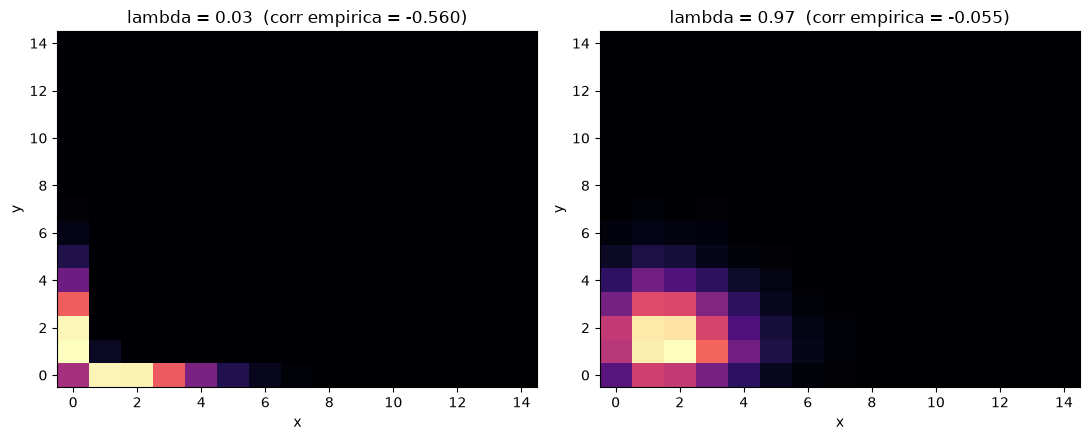

In [6]:
def sample_poisson_neg_corr(lambda_x, lambda_y, lam, n, rng, burn_in=50):
    """Amostra n pares (x,y) da distribuicao (6) via Gibbs sampling nas condicionais
    X|Y=y ~ Poisson(lambda_x * lam**y) e Y|X=x ~ Poisson(lambda_y * lam**x)."""
    x = rng.poisson(lambda_x, size=n)
    y = rng.poisson(lambda_y, size=n)

    for _ in range(burn_in):
        x = rng.poisson(lambda_x * lam ** y)
        y = rng.poisson(lambda_y * lam ** x)

    return x, y


# mesmos parametros usados nas Figuras 5 e 6 do artigo [1], pra comparar com os valores
# de correlacao que os autores reportam (-0.556 e -0.057, respectivamente)
lambda_x, lambda_y = 2, 2

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

for j, lam in enumerate([0.03, 0.97]):
    x, y = sample_poisson_neg_corr(lambda_x, lambda_y, lam, 20_000, rng)
    corr = np.corrcoef(x, y)[0, 1]
    ax[j].hist2d(x, y, bins=np.arange(-0.5, 15.5), cmap='magma')
    ax[j].set_title(f'lambda = {lam}  (corr empirica = {corr:.3f})')
    ax[j].set_xlabel('x')
    ax[j].set_ylabel('y')
    print(f"lambda = {lam}:  corr empirica = {corr:.3f}   (artigo [1], Fig. {5 if lam==0.03 else 6}: "
          f"{-0.556 if lam==0.03 else -0.057})")

plt.tight_layout()
plt.show()


## Conclusão

- Nos itens (a)–(c), tanto amostrar direto da PMF truncada da Eq. (5) quanto construir $X=Z_1+Z_3$,
  $Y=Z_2+Z_3$ por soma de Poissons independentes dão o mesmo resultado (empiricamente as médias e a
  correlação batem entre os dois métodos, e com a fórmula analítica $\rho_{X,Y}=\theta/\sqrt{\mu_X\mu_Y}$).
- Como $Cov(X,Y)=\theta \ge 0$ nesses métodos, eles só conseguem gerar correlação positiva (ou nula, se
  $\theta=0$) — nunca negativa, porque a covariância vem inteira da parte "compartilhada" $Z_3$, que é uma
  variância e por isso não pode ser negativa.
- Pra gerar correlação negativa foi preciso trocar de abordagem: em vez de somar variáveis independentes,
  usar a distribuição de Ghosh, Marques & Chakraborty (2021) [1], definida pelas condicionais Poisson
  $X|Y=y \sim \text{Poisson}(\lambda_X\lambda^y)$ e $Y|X=x \sim \text{Poisson}(\lambda_Y\lambda^x)$. Como a
  constante de normalização dessa distribuição não tem forma fechada simples, amostrei via Gibbs sampling
  usando só as condicionais — e a correlação empírica obtida (~-0.556 para $\lambda=0.03$ e ~-0.057 para
  $\lambda=0.97$, com $\lambda_X=\lambda_Y=2$) ficou bem próxima dos valores que os próprios autores
  reportam nas Figuras 5 e 6 do artigo, o que dá confiança de que o amostrador está correto.
- Fica claro também porque $\lambda \to 1$ aproxima $X$ e $Y$ da independência (o artigo destaca isso): as
  condicionais deixam de depender da variável condicionante quando $\lambda=1$.